/home/alejo/.virtualenvs/datascience-venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- ESTADÍSTICAS DESCRIPTIVAS ---
count    4666.000000
mean       13.273253
std        15.772625
min         1.000000
25%         3.000000
50%         8.000000
75%        17.000000
max       128.000000
Name: y, dtype: float64

Total de registros analizados: 61933
Rango de fechas: 2010-01-03 00:00:00 a 2024-03-29 00:00:00


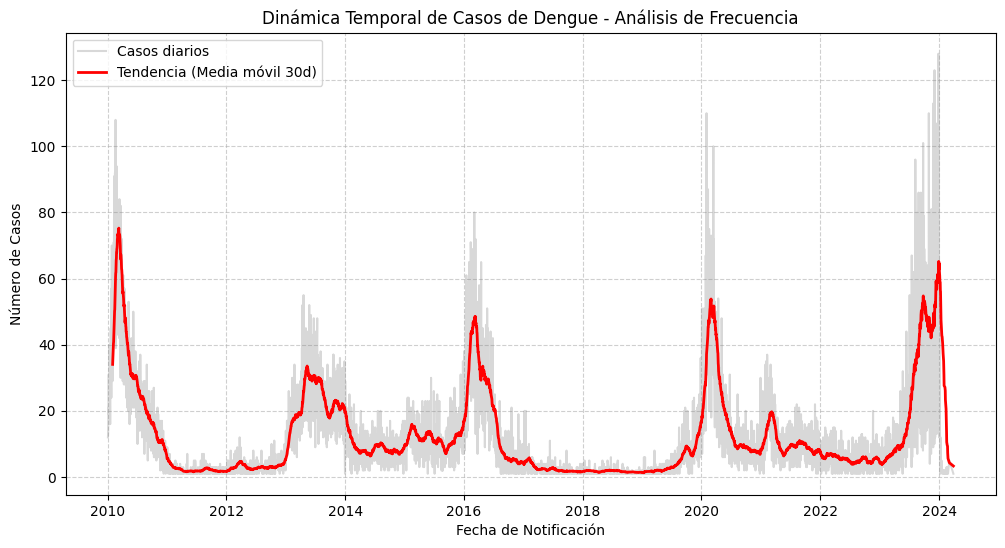

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast

# 1. Carga y limpieza
df = pd.read_csv('datos_dengue.csv')
df['fec_not'] = pd.to_datetime(df['fec_not'])

# 2. Transformación al Formato Nixtla
# Agrupamos por fecha para obtener el conteo de casos (nuestra variable 'y')
df_counts = df.groupby('fec_not').size().reset_index(name='y')
df_counts['ds'] = df_counts['fec_not']
df_counts['unique_id'] = 'Dengue_Cali' # Identificador único para el modelo global

# Asegurar continuidad en la serie (rellenar días con 0 casos si es necesario)
df_nixtla = df_counts[['unique_id', 'ds', 'y']].sort_values('ds')

# 3. Análisis Descriptivo Avanzado
stats = df_nixtla['y'].describe()
rolling_mean = df_nixtla.set_index('ds')['y'].rolling(window=30).mean()

print("--- ESTADÍSTICAS DESCRIPTIVAS ---")
print(stats)
print(f"\nTotal de registros analizados: {len(df)}")
print(f"Rango de fechas: {df_nixtla['ds'].min()} a {df_nixtla['ds'].max()}")

# 4. Visualización para el informe
plt.figure(figsize=(12, 6))
plt.plot(df_nixtla['ds'], df_nixtla['y'], alpha=0.3, label='Casos diarios', color='gray')
plt.plot(df_nixtla['ds'], rolling_mean, label='Tendencia (Media móvil 30d)', color='red', linewidth=2)
plt.title("Dinámica Temporal de Casos de Dengue - Análisis de Frecuencia")
plt.xlabel("Fecha de Notificación")
plt.ylabel("Número de Casos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()